# Deep Learning: Next-Session Browsing Category & Profile Forecasting

This notebook is the **experimentation** workspace for the multi-task PyTorch LSTM. It does not just call the pipeline once — it:

1. Builds and inspects the gold sliding-window sequence dataset.
2. Establishes a **naive baseline** to beat.
3. Runs **Optuna hyperparameter tuning** (trials logged to MLflow).
4. Trains the **final model with the best parameters**.
5. Plots **training vs validation loss curves**.
6. Evaluates the held-out test split, including **per-category accuracy**.
7. Demonstrates a live **next-session forecast** with full probability distribution.

Every experiment, parameter, metric, loss curve, and model artifact is tracked in **MLflow**.


## 1. Environment Setup & MLflow

In [1]:
%matplotlib inline
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd


def _find_project_root() -> Path:
    current = Path.cwd()

    while current != current.parent:
        if (current / "src").is_dir():
            return current

        current = current.parent

    raise RuntimeError("Could not locate the project root (missing src/ directory).")


PROJECT_ROOT = _find_project_root()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [2]:
import torch

from src.deep_learning.dataset_builder import DatasetBuilder
from src.deep_learning.lstm_pipeline import LSTMPipeline
from src.deep_learning.lstm_tuner import LSTMTuner
from src.utils.mlflow_utils import get_tracking_uri, setup_mlflow

setup_mlflow()
print(f"MLflow Tracking URI: {get_tracking_uri()}")
print(f"Device: {'cuda' if torch.cuda.is_available() else 'cpu'}")

/home/abishek/Projects/intelligent-browser-behaviour-analytics-platform/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


2026-08-13 08:24:04,001 | INFO     | src.utils.mlflow_utils | MLflow tracking URI: file:///home/abishek/Projects/intelligent-browser-behaviour-analytics-platform/mlruns


MLflow Tracking URI: file:///home/abishek/Projects/intelligent-browser-behaviour-analytics-platform/mlruns
Device: cpu


## 2. Gold Sequence Dataset

A sliding window over chronologically ordered sessions. Each sample uses the previous
`sequence_length = 5` sessions to predict the next session's numeric profile (regression)
and dominant category (classification).

In [3]:
builder = DatasetBuilder(sequence_length=5)
gold = builder.run()
sequences = gold["behavior_sequences"]
session_features = gold["session_features"]

print(f"Sessions: {len(session_features):,} | Features: {len(builder.feature_columns)}")
print(f"Sequence samples: {len(sequences):,}")
print(
    f"Sequence shape: {len(sequences.iloc[0]['feature_vectors'])} timesteps x "
    f"{len(sequences.iloc[0]['feature_vectors'][0])} features"
)
sequences[["sequence_id", "target_session_id", "target_category"]].head(10)

2026-08-13 08:24:04,026 | INFO     | src.deep_learning.dataset_builder | Starting Gold dataset build.


2026-08-13 08:24:04,057 | INFO     | src.deep_learning.dataset_builder | Session features built | sessions=829 | columns=33


2026-08-13 08:24:04,288 | INFO     | src.deep_learning.dataset_builder | Behavior sequences built | samples=824 | sequence_length=5 | features=32


2026-08-13 08:24:04,298 | INFO     | src.deep_learning.dataset_builder | Gold session features dataset saved: /home/abishek/Projects/intelligent-browser-behaviour-analytics-platform/data/gold/session_features.parquet | rows=829 | columns=33


2026-08-13 08:24:04,335 | INFO     | src.deep_learning.dataset_builder | Gold behavior sequences dataset saved: /home/abishek/Projects/intelligent-browser-behaviour-analytics-platform/data/gold/behavior_sequences.parquet | rows=824 | columns=8


2026-08-13 08:24:04,336 | INFO     | src.deep_learning.dataset_builder | Gold dataset build completed.


Sessions: 829 | Features: 32
Sequence samples: 824
Sequence shape: 5 timesteps x 32 features


,sequence_id,target_session_id,target_category
0,0,6,Search/Reference
1,1,7,Social Media
2,2,8,Search/Reference
3,3,9,Social Media
4,4,10,Social Media
5,5,11,Social Media
6,6,12,Entertainment/Media
7,7,13,Social Media
8,8,14,Social Media
9,9,15,Search/Reference


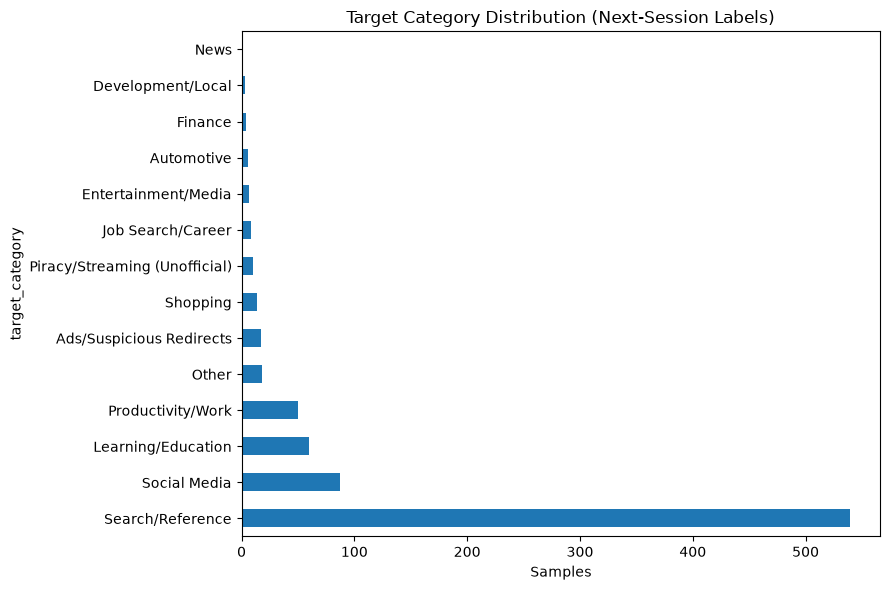

target_category
Search/Reference                 539
Social Media                      87
Learning/Education                60
Productivity/Work                 50
Other                             18
Ads/Suspicious Redirects          17
Shopping                          14
Piracy/Streaming (Unofficial)     10
Job Search/Career                  8
Entertainment/Media                7
Automotive                         6
Finance                            4
Development/Local                  3
News                               1
Name: count, dtype: int64


In [4]:
target_counts = sequences["target_category"].astype(str).value_counts()
target_counts.plot(kind="barh", figsize=(9, 6), color="#1f77b4")
plt.title("Target Category Distribution (Next-Session Labels)")
plt.xlabel("Samples")
plt.tight_layout()
plt.show()
print(target_counts)

## 3. Naive Baseline (what the LSTM must beat)

In [5]:
# Most-frequent-class baseline on the same chronological test split as the pipeline.


def _split_frame(frame, train_ratio=0.8, validation_ratio=0.9):
    train_end = max(1, int(len(frame) * train_ratio))
    validation_end = max(2, int(len(frame) * validation_ratio))
    return frame.iloc[train_end:validation_end], frame.iloc[validation_end:]


_, test = _split_frame(sequences)

# Baseline 1: always predict the most common category seen in train.
train = sequences.iloc[: max(1, int(len(sequences) * 0.8))]
most_common = train["target_category"].astype(str).mode().iloc[0]
baseline_acc = (test["target_category"].astype(str) == most_common).mean()

# Baseline 2: predict that the next session repeats the last observed category.
test_categories = test["target_category"].astype(str).to_numpy()
persistence_acc = (test_categories[1:] == test_categories[:-1]).mean()

print(f"Most-frequent-class baseline accuracy: {baseline_acc:.3f}")
print(f"Persistence (repeat-last) baseline accuracy: {persistence_acc:.3f}")

Most-frequent-class baseline accuracy: 0.651
Persistence (repeat-last) baseline accuracy: 0.585


## 4. Optuna Hyperparameter Tuning

The search space (hidden size, layers, dropout, learning rate, batch size, task weight)
is declared in `config/models.yaml`. Every trial reuses the pipeline's chronological
training path and is logged to the `browser-behavior-lstm-tuning` MLflow experiment.

In [6]:
tuner = LSTMTuner(n_trials=8, track_mlflow=True)
tuning = tuner.run()
print(f"Trials completed: {tuning.n_trials}")
print(f"Best validation loss: {tuning.best_value:.4f}")
print("Best parameters:")
for key, value in tuning.best_params.items():
    print(f"  {key:22s} {value:.6f}" if isinstance(value, float) else f"  {key:22s} {value}")

2026-08-13 08:24:04,758 | INFO     | src.deep_learning.lstm_tuner | Tuning data prepared | train=659 | validation=82 | categories=14


  0%|          | 0/8 [00:00<?, ?it/s]

2026-08-13 08:24:12,323 | INFO     | src.deep_learning.lstm_pipeline | LSTM trained | epochs=14 | best_validation_loss=1.7308


2026-08-13 08:24:12,335 | INFO     | src.utils.mlflow_utils | MLflow tracking URI: file:///home/abishek/Projects/intelligent-browser-behaviour-analytics-platform/mlruns


Best trial: 2. Best value: 1.74646:   0%|          | 0/8 [00:07<?, ?it/s]

...


2026-08-13 08:24:33,875 | INFO     | src.utils.mlflow_utils | MLflow tracking URI: file:///home/abishek/Projects/intelligent-browser-behaviour-analytics-platform/mlruns


2026-08-13 08:24:34,525 | INFO     | src.deep_learning.lstm_tuner | MLflow tuning summary run logged | run_id=0a810ccbb1c14eea9a35fb4876fbc000


2026-08-13 08:24:34,533 | INFO     | src.deep_learning.lstm_tuner | LSTM tuning completed | trials=10 | best_validation_loss=1.5649


2026-08-13 08:24:34,536 | INFO     | src.deep_learning.lstm_tuner | LSTM best parameters: {'hidden_size': 134, 'num_layers': 3, 'dropout': 0.09983689107917987, 'learning_rate': 0.0010677482709481358, 'batch_size': 45, 'classification_weight': 0.14180537144799796}


Trials completed: 10
Best validation loss: 1.5649
Best parameters:
  hidden_size            134
  num_layers             3
  dropout                0.099837
  learning_rate          0.001068
  batch_size             45
  classification_weight  0.141805


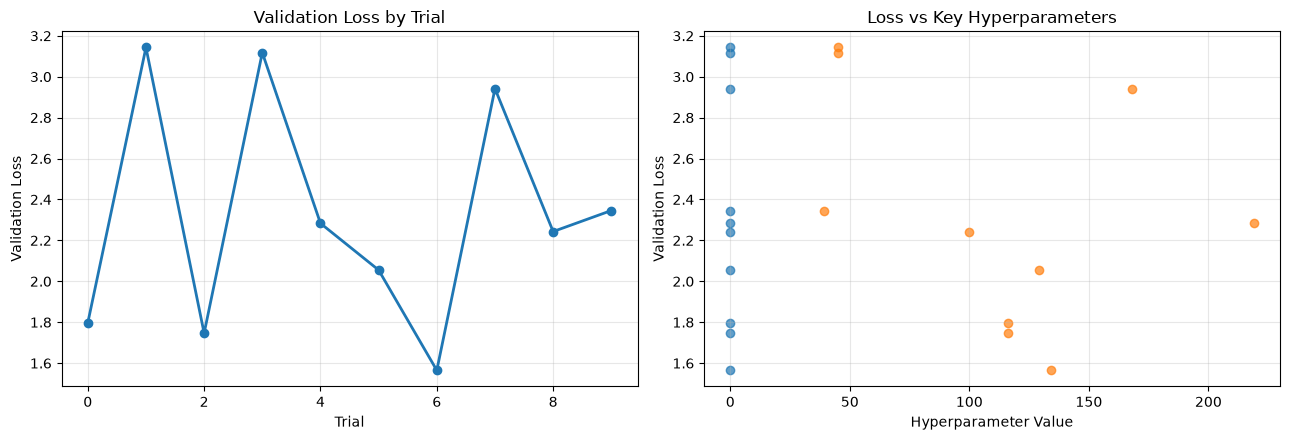

In [7]:
# Trial history: validation loss across the sampled hyperparameters.
trials_df = pd.DataFrame(
    [
        {"trial": t.number, "validation_loss": t.value, **t.params}
        for t in tuning.study.trials
        if t.value is not None
    ]
).sort_values("trial")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(trials_df["trial"], trials_df["validation_loss"], marker="o", linewidth=2)
axes[0].set_title("Validation Loss by Trial")
axes[0].set_xlabel("Trial")
axes[0].set_ylabel("Validation Loss")
axes[0].grid(True, alpha=0.3)

for feature in ["learning_rate", "hidden_size"]:
    if feature in trials_df.columns:
        axes[1].scatter(trials_df[feature], trials_df["validation_loss"], alpha=0.7)
axes[1].set_title("Loss vs Key Hyperparameters")
axes[1].set_xlabel("Hyperparameter Value")
axes[1].set_ylabel("Validation Loss")
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Final Training with Best Parameters

In [8]:
pipeline = LSTMPipeline(overrides=dict(tuning.best_params))
results = pipeline.run()

print("=== Final model metrics (held-out test split) ===")
for name, value in results["metrics"].items():
    print(f"  {name:20s} {value:.4f}")
print(f"MLflow run id: {results['run_id']}")
print(f"Trained model saved to: {pipeline.model_path}")

2026-08-13 08:24:41,425 | INFO     | src.deep_learning.lstm_pipeline | LSTM trained | epochs=24 | best_validation_loss=1.5259


2026-08-13 08:24:41,484 | INFO     | src.deep_learning.lstm_pipeline | LSTM model saved: /home/abishek/Projects/intelligent-browser-behaviour-analytics-platform/models/lstm_next_session.pt


2026-08-13 08:24:41,502 | INFO     | src.utils.mlflow_utils | MLflow tracking URI: file:///home/abishek/Projects/intelligent-browser-behaviour-analytics-platform/mlruns


2026/08/13 08:24:41 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


2026/08/13 08:24:41 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.


...

Registered model 'NextSessionLSTMPredictor' already exists. Creating a new version of this model...
Created version '6' of model 'NextSessionLSTMPredictor'.
2026/08/13 08:24:49 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


2026/08/13 08:24:57 WARNING mlflow.sklearn: Model was missing function: predict. Not logging python_function flavor!


2026/08/13 08:25:10 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


2026-08-13 08:25:10,500 | INFO     | src.deep_learning.lstm_pipeline | LSTM pipeline completed | test_samples=83 | rmse=390.0180


=== Final model metrics (held-out test split) ===
  mse                  152114.0332
  rmse                 390.0180
  mae                  97.7052
  category_accuracy    0.6506
MLflow run id: 244f46860e244109b2aa3aaff457d442
Trained model saved to: /home/abishek/Projects/intelligent-browser-behaviour-analytics-platform/models/lstm_next_session.pt


## 6. Training & Validation Loss Curves

In [9]:
history = results["history"]
epochs = [entry["epoch"] for entry in history]
train_loss = [entry["train_loss"] for entry in history]
val_loss = [entry["validation_loss"] for entry in history]

plt.figure(figsize=(9, 5))
plt.plot(epochs, train_loss, label="Training Loss", marker="o")
plt.plot(epochs, val_loss, label="Validation Loss", marker="o", color="#1f77b4")
plt.title("Multi-Task LSTM Training History (best hyperparameters)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

/tmp/ipykernel_41892/992716449.py:15: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## 7. Held-Out Test Evaluation

In [10]:
predictions = results["predictions"]
print(f"Evaluated test sessions: {len(predictions)}")
predictions.head(10)

Evaluated test sessions: 83


,target_session_id,actual_category,predicted_category,category_correct,actual_hour,predicted_hour,actual_day_of_week_num,predicted_day_of_week_num,actual_is_weekend,predicted_is_weekend,...,actual_category_switch_count,predicted_category_switch_count,actual_time_of_day_Morning,predicted_time_of_day_Morning,actual_time_of_day_Afternoon,predicted_time_of_day_Afternoon,actual_time_of_day_Evening,predicted_time_of_day_Evening,actual_time_of_day_Night,predicted_time_of_day_Night
0,747,Learning/Education,Search/Reference,False,16.0,10.570837,4.0,3.422025,0.0,0.305824,...,20.0,1.471265,0.0,0.047829,1.0,0.329185,0.0,0.242891,0.0,0.411741
1,748,Productivity/Work,Search/Reference,False,1.0,10.288086,5.0,3.028452,1.0,0.214784,...,21.0,2.100976,0.0,-0.032433,0.0,0.289895,0.0,0.259291,1.0,0.478769
2,749,Productivity/Work,Search/Reference,False,4.0,3.924605,5.0,4.063940,1.0,0.296460,...,11.0,3.944914,0.0,0.269005,0.0,-0.062039,0.0,0.077541,1.0,0.749664
3,750,Search/Reference,Search/Reference,True,5.0,4.955914,5.0,5.011447,1.0,0.534032,...,26.0,5.417941,1.0,0.603390,0.0,0.016051,0.0,0.017006,0.0,0.456379
4,751,Search/Reference,Search/Reference,True,9.0,7.736951,5.0,5.453336,1.0,0.696358,...,14.0,6.344886,1.0,0.792782,0.0,0.110373,0.0,0.006042,0.0,0.164538
5,752,Learning/Education,Search/Reference,False,11.0,10.640345,5.0,5.696963,1.0,0.740574,...,22.0,6.636682,1.0,0.718460,0.0,0.301973,0.0,0.043931,0.0,0.031739
6,753,Learning/Education,Search/Reference,False,12.0,12.776495,5.0,5.678144,1.0,0.740759,...,0.0,6.738599,0.0,0.542361,1.0,0.510882,0.0,0.078586,0.0,-0.042306
7,754,Learning/Education,Search/Reference,False,13.0,13.252895,5.0,5.692725,1.0,0.828077,...,0.0,5.426578,0.0,0.306486,1.0,0.660953,0.0,0.090071,0.0,-0.032854
8,755,Learning/Education,Search/Reference,False,14.0,13.249309,5.0,5.569952,1.0,0.838968,...,28.0,4.191230,0.0,0.079257,1.0,0.766638,0.0,0.112268,0.0,0.035506
9,756,Search/Reference,Search/Reference,True,17.0,14.874482,5.0,5.076579,1.0,0.830177,...,0.0,5.028041,0.0,-0.070387,0.0,0.949683,1.0,0.129181,0.0,-0.032831


In [11]:
# Per-category accuracy reveals where the model is strong / weak.
per_category = (
    predictions.groupby("actual_category")
    .agg(samples=("category_correct", "size"), correct=("category_correct", "sum"))
    .assign(accuracy=lambda df: df["correct"] / df["samples"])
    .sort_values("accuracy", ascending=False)
)
per_category

,samples,correct,accuracy
actual_category,,,
Search/Reference,54,54,1.0
Job Search/Career,1,0,0.0
Automotive,1,0,0.0
Learning/Education,11,0,0.0
Other,3,0,0.0
Productivity/Work,8,0,0.0
Social Media,5,0,0.0


In [12]:
per_category["accuracy"].plot(kind="bar", figsize=(10, 5), color="#2ca02c")
plt.title("LSTM Accuracy by Actual Category (held-out test)")
plt.ylabel("Accuracy")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

/tmp/ipykernel_41892/2116397506.py:7: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## 8. Live Next-Session Forecast

Load the saved checkpoint and predict the next session from the last 5 sessions
of the held-out test set, returning the full category probability distribution.

In [13]:
restored = LSTMPipeline(track_mlflow=False)
restored.load()

# Recover the gold session features and build a 5-session window.
session_frame = pd.read_parquet(PROJECT_ROOT / "data" / "gold" / "session_features.parquet")
matrix, columns = DatasetBuilder()._build_feature_matrix(session_frame)
session_frame[columns] = matrix
sorted_sessions = session_frame.sort_values(["session_start", "session_id"])
last_window = sorted_sessions.iloc[-5:][columns].to_numpy()

forecast = restored.predict_distribution(last_window)
print(
    f"Forecasted next category: {forecast['predicted_category']} "
    f"(confidence {forecast['category_confidence']:.1%})"
)

probs = forecast["category_probabilities"]
probs_df = pd.DataFrame({"category": probs.keys(), "probability": probs.values()}).sort_values(
    "probability", ascending=False
)
probs_df.head(8)

Forecasted next category: Search/Reference (confidence 61.3%)


,category,probability
11,Search/Reference,0.612764
6,Learning/Education,0.110504
10,Productivity/Work,0.067900
13,Social Media,0.043296
0,Ads/Suspicious Redirects,0.034082
9,Piracy/Streaming (Unofficial),0.033930
3,Entertainment/Media,0.021405
8,Other,0.016086


In [14]:
plt.figure(figsize=(9, 4.5))
plt.barh(probs_df["category"].head(8)[::-1], probs_df["probability"].head(8)[::-1], color="#ff7f0e")
plt.xlabel("Probability")
plt.title("Next-Session Category Probability Distribution")
plt.tight_layout()
plt.show()

/tmp/ipykernel_41892/2017506375.py:6: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()
